In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier , AdaBoostClassifier , BaggingClassifier , ExtraTreesClassifier, VotingClassifier , StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score,f1_score

## **Dataset Load**

In [2]:
df = pd.read_csv("Student_performance_data _.csv")

## See the first 5 rows

In [3]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


## See the last 5 rows

In [4]:
df.tail()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0
2391,3392,16,1,0,2,17.819907,13,0,2,0,0,0,1,2.140014,1.0


## Dataset Shape

In [5]:
df.shape

(2392, 15)

## Dataset Columns

In [6]:
df.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

## Dataset Info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


## Statistical Analysis

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
StudentID,2392.0,2196.500000,690.655244,1001.000000,1598.750000,2196.500000,2794.250000,3392.000000
Age,2392.0,16.468645,1.123798,15.000000,15.000000,16.000000,17.000000,18.000000
Gender,2392.0,0.510870,0.499986,0.000000,0.000000,1.000000,1.000000,1.000000
Ethnicity,2392.0,0.877508,1.028476,0.000000,0.000000,0.000000,2.000000,3.000000
ParentalEducation,2392.0,1.746237,1.000411,0.000000,1.000000,2.000000,2.000000,4.000000
StudyTimeWeekly,2392.0,9.771992,5.652774,0.001057,5.043079,9.705363,14.408410,19.978094
Absences,2392.0,14.541388,8.467417,0.000000,7.000000,15.000000,22.000000,29.000000
Tutoring,2392.0,0.301421,0.458971,0.000000,0.000000,0.000000,1.000000,1.000000
ParentalSupport,2392.0,2.122074,1.122813,0.000000,1.000000,2.000000,3.000000,4.000000
Extracurricular,2392.0,0.383361,0.486307,0.000000,0.000000,0.000000,1.000000,1.000000


## Dataset Datatype

In [9]:
df.dtypes

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

## EDA 

## Dataset missing value check


In [10]:
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

## Duplicate value check

In [11]:
df.duplicated().sum()

np.int64(0)


## Visualization

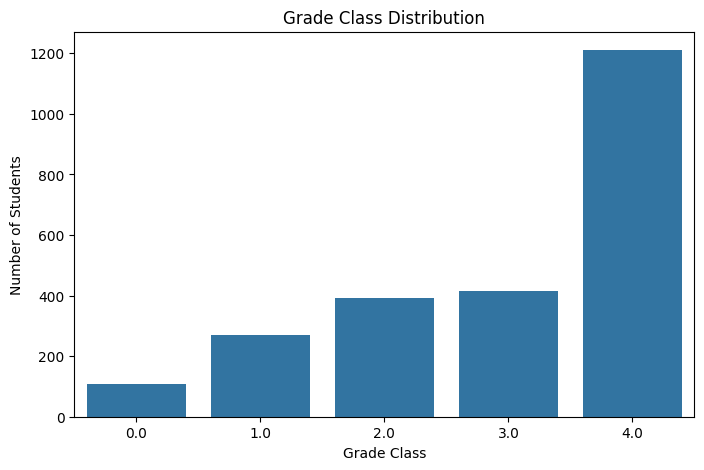

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='GradeClass')
plt.title('Grade Class Distribution')
plt.xlabel('Grade Class')
plt.ylabel('Number of Students')
plt.show()

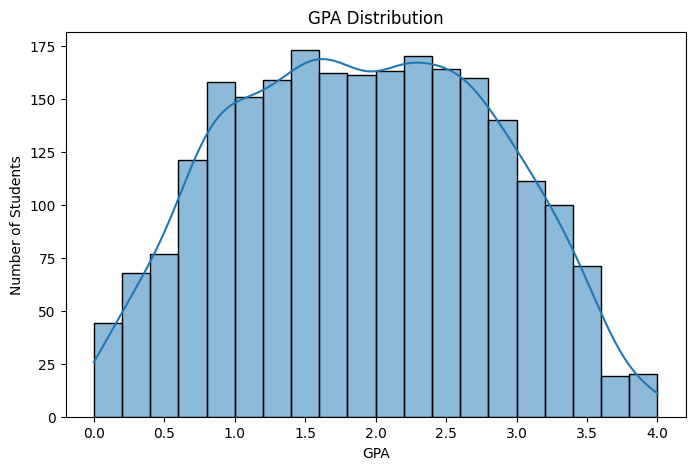

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='GPA', bins=20, kde=True)
plt.title('GPA Distribution')
plt.xlabel('GPA')
plt.ylabel('Number of Students')
plt.show()

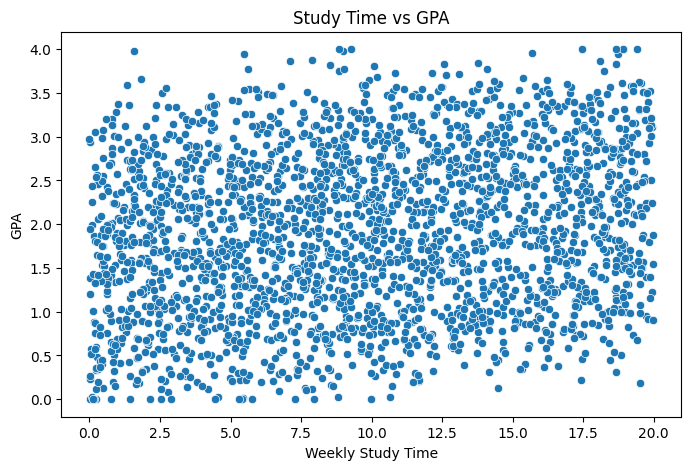

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='StudyTimeWeekly', y='GPA')
plt.title('Study Time vs GPA')
plt.xlabel('Weekly Study Time')
plt.ylabel('GPA')
plt.show()

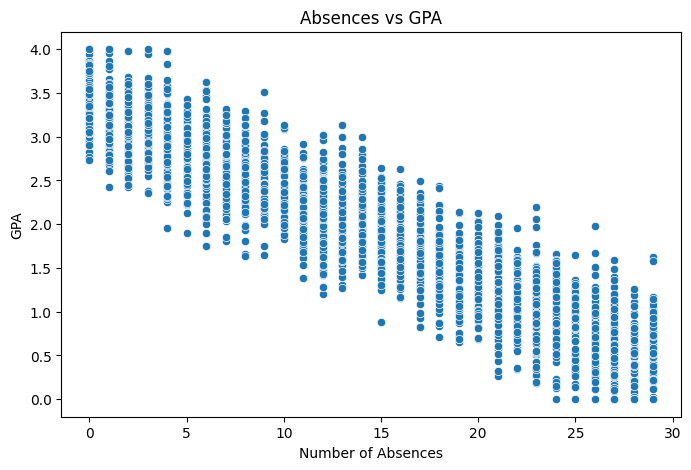

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Absences', y='GPA')
plt.title('Absences vs GPA')
plt.xlabel('Number of Absences')
plt.ylabel('GPA')
plt.show()

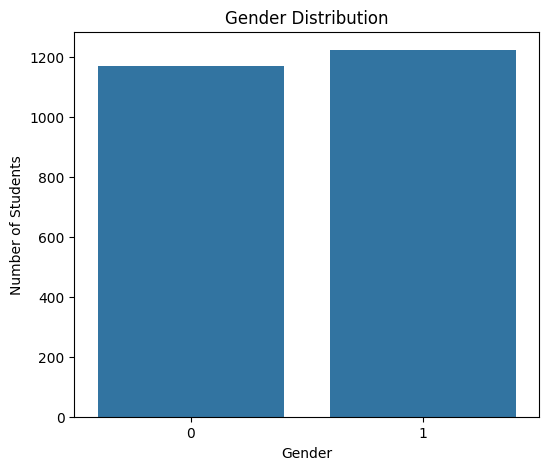

In [16]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.show()

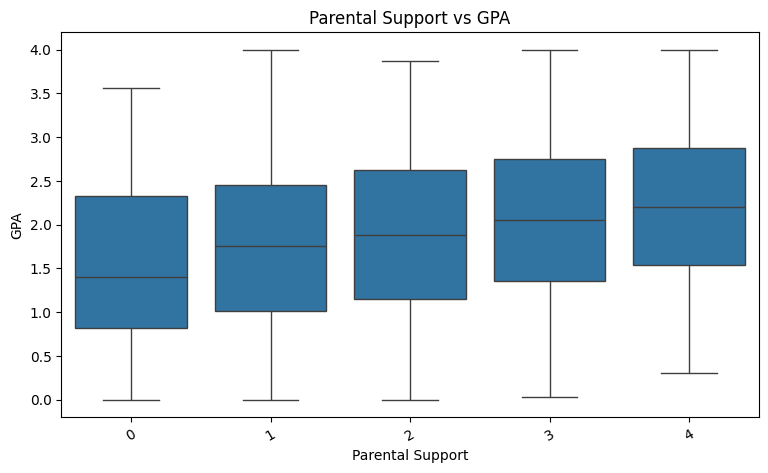

In [17]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='ParentalSupport', y='GPA')
plt.title('Parental Support vs GPA')
plt.xlabel('Parental Support')
plt.ylabel('GPA')
plt.xticks(rotation=30)
plt.show()

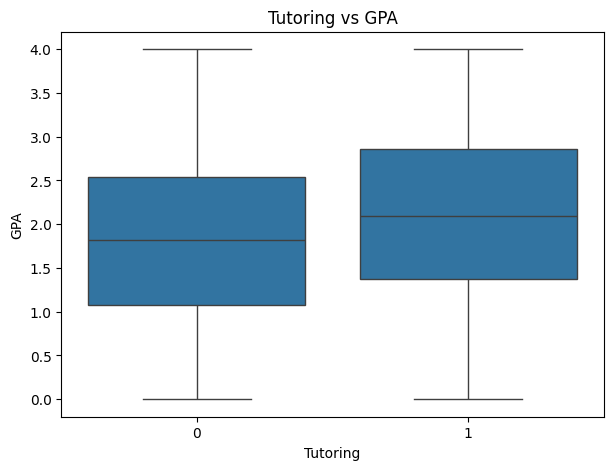

In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Tutoring', y='GPA')
plt.title('Tutoring vs GPA')
plt.xlabel('Tutoring')
plt.ylabel('GPA')
plt.show()

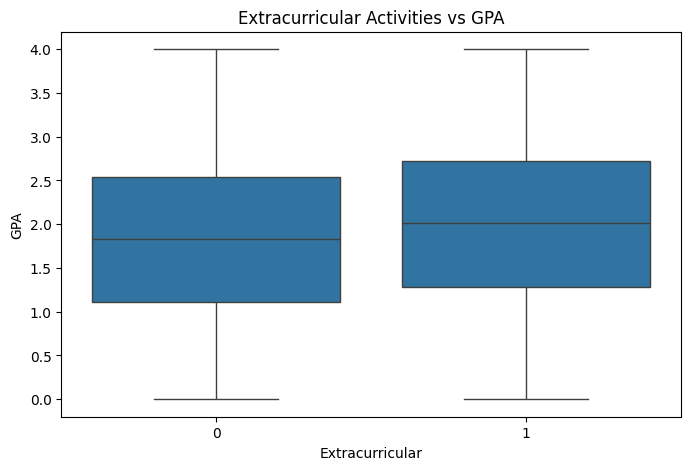

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Extracurricular', y='GPA')
plt.title('Extracurricular Activities vs GPA')
plt.xlabel('Extracurricular')
plt.ylabel('GPA')
plt.show()

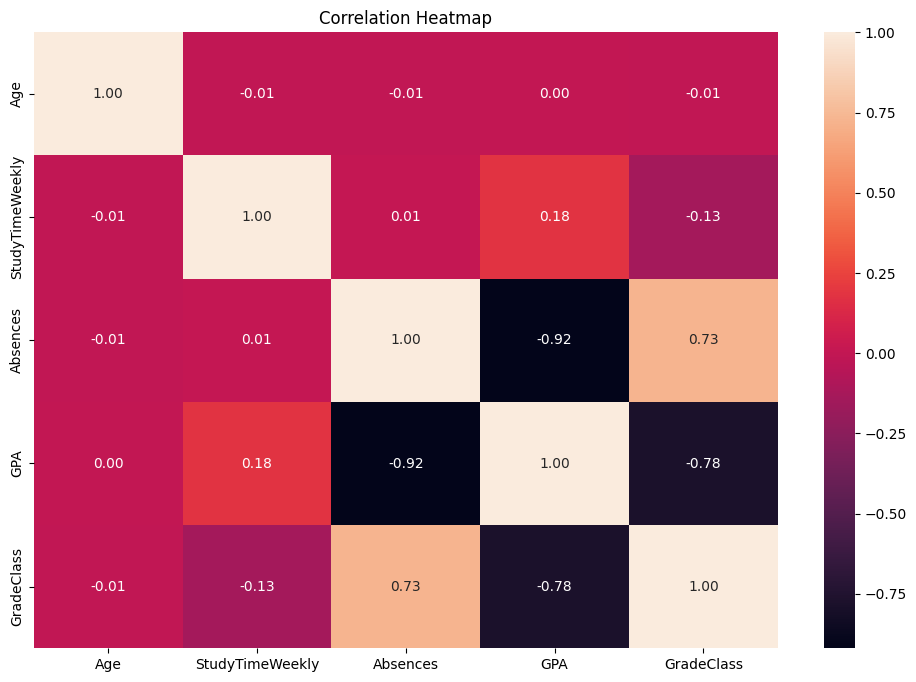

In [20]:
plt.figure(figsize=(12,8))

numeric_cols = [
    'Age',
    'StudyTimeWeekly',
    'Absences',
    'GPA',
    'GradeClass'
]

corr = df[numeric_cols].corr()

sns.heatmap(corr,annot=True,cmap='rocket',fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

In [21]:
x = df.drop(['GradeClass'],axis = 1)
y = df['GradeClass']

In [22]:
xtrain , xtest, ytrain , ytest = train_test_split(x,y, test_size = .75,random_state = 42)

# Performing Random Forest

Training Score :  100.0
Testing Score :  90.96989966555184
Predict successfully 
Accuracy Score :  90.96989966555184
              precision    recall  f1-score   support

         0.0       0.84      0.34      0.48        77
         1.0       0.79      0.84      0.81       197
         2.0       0.92      0.89      0.91       295
         3.0       0.86      0.92      0.89       306
         4.0       0.95      0.98      0.96       919

    accuracy                           0.91      1794
   macro avg       0.87      0.79      0.81      1794
weighted avg       0.91      0.91      0.90      1794



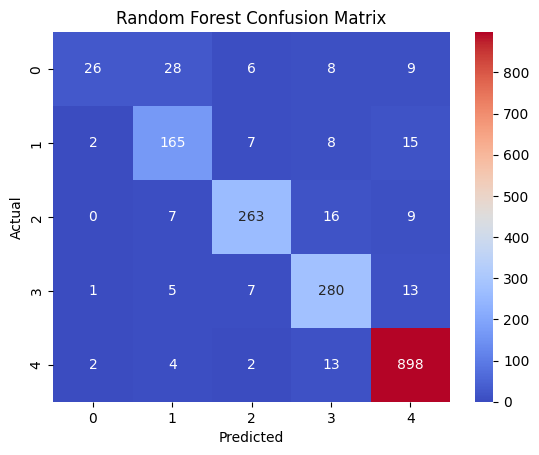

In [23]:
rf = RandomForestClassifier()
rf.fit(xtrain,ytrain)

print("Training Score : ", rf.score(xtrain,ytrain)*100)
print("Testing Score : ", rf.score(xtest,ytest)*100)

# Prediction 

y_pred_rf = rf.predict(xtest)
print("Predict successfully ")

# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score,f1_score

#accuracy_score 
ac = accuracy_score(ytest , y_pred_rf)
print("Accuracy Score : ", ac *100)

#classification report
cr = classification_report(ytest,y_pred_rf)
print(cr)
#Confusion Matrix
cm = confusion_matrix(ytest, y_pred_rf)

sns.heatmap(cm , annot = True , cmap = 'coolwarm', fmt = 'd')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

 # Performing Decision Tree 

Training Score :  100.0
Testing Score :  92.64214046822742
Predict successfully 
Accuracy Score :  92.64214046822742
              precision    recall  f1-score   support

         0.0       0.73      0.74      0.74        77
         1.0       0.87      0.85      0.86       197
         2.0       0.89      0.92      0.90       295
         3.0       0.91      0.91      0.91       306
         4.0       0.97      0.97      0.97       919

    accuracy                           0.93      1794
   macro avg       0.87      0.88      0.88      1794
weighted avg       0.93      0.93      0.93      1794



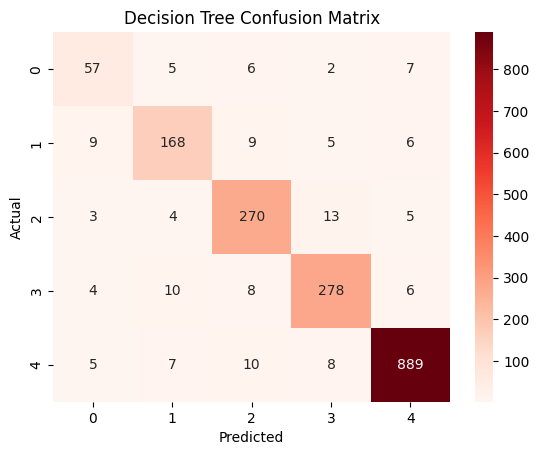

In [24]:
dt = DecisionTreeClassifier()
dt.fit(xtrain,ytrain)

print("Training Score : ", dt.score(xtrain,ytrain)*100)
print("Testing Score : ", dt.score(xtest,ytest)*100)

# Prediction 

y_pred_dt = dt.predict(xtest)
print("Predict successfully ")

# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score,f1_score

#accuracy_score 
ac = accuracy_score(ytest , y_pred_dt)
print("Accuracy Score : ", ac *100)

#classification report
cr = classification_report(ytest,y_pred_dt)
print(cr)
#Confusion Matrix
cm = confusion_matrix(ytest, y_pred_dt)

sns.heatmap(cm , annot = True , cmap = 'Reds', fmt = 'd')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Performing XGboost Classifier

Training Score :  100.0
Testing Score :  91.69453734671126
Predict successfully
Accuracy Score :  91.69453734671126
              precision    recall  f1-score   support

         0.0       0.68      0.60      0.63        77
         1.0       0.83      0.88      0.86       197
         2.0       0.92      0.93      0.92       295
         3.0       0.87      0.90      0.88       306
         4.0       0.97      0.95      0.96       919

    accuracy                           0.92      1794
   macro avg       0.85      0.85      0.85      1794
weighted avg       0.92      0.92      0.92      1794



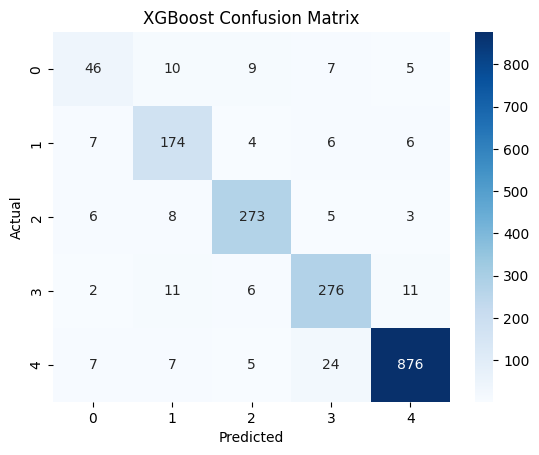

In [25]:
# XGBoost Model
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Training
xgb.fit(xtrain, ytrain)

# Scores
print("Training Score : ", xgb.score(xtrain, ytrain) * 100)
print("Testing Score : ", xgb.score(xtest, ytest) * 100)

# Prediction
y_pred_xgb = xgb.predict(xtest)
print("Predict successfully")

# Accuracy Score
ac = accuracy_score(ytest, y_pred_xgb)
print("Accuracy Score : ", ac * 100)

# Classification Report
cr = classification_report(ytest, y_pred_xgb)
print(cr)

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_xgb)

sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

# Performing SVM classifier

Training Score :  80.93645484949833
Testing Score :  79.15273132664437
Accuracy Score :  79.15273132664437
              precision    recall  f1-score   support

         0.0       0.20      0.18      0.19        77
         1.0       0.61      0.65      0.63       197
         2.0       0.67      0.65      0.66       295
         3.0       0.73      0.67      0.70       306
         4.0       0.93      0.96      0.95       919

    accuracy                           0.79      1794
   macro avg       0.63      0.62      0.62      1794
weighted avg       0.79      0.79      0.79      1794



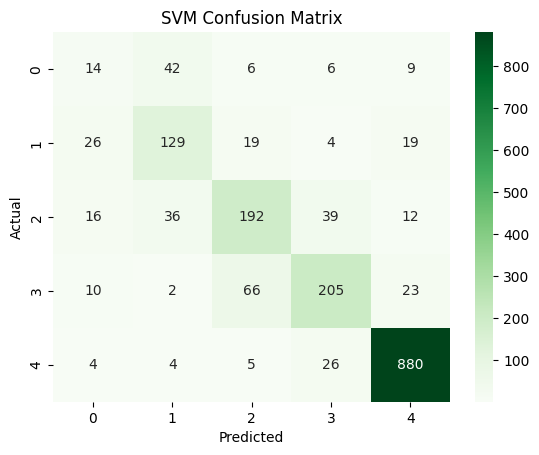

In [ ]:
svm = SVC(kernel='linear', random_state=42)


# Training
svm.fit(xtrain, ytrain) 
print("Training Score : ", svm.score(xtrain, ytrain) * 100)
#testing
print("Testing Score : ", svm.score(xtest, ytest) * 100)

# Prediction
y_pred_svm = svm.predict(xtest)

# Accuracy Score
ac = accuracy_score(ytest, y_pred_svm)
print("Accuracy Score : ", ac * 100)

# Classification Report
cr = classification_report(ytest, y_pred_svm)
print(cr)

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_svm)
sns.heatmap(cm, annot=True, cmap='Greens', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

# Performing Gradient Boosting Classifier 

Training Score :  100.0
Testing Score :  92.47491638795987
Accuracy Score :  92.47491638795987
              precision    recall  f1-score   support

         0.0       0.62      0.71      0.67        77
         1.0       0.87      0.84      0.86       197
         2.0       0.89      0.92      0.90       295
         3.0       0.91      0.91      0.91       306
         4.0       0.98      0.97      0.97       919

    accuracy                           0.92      1794
   macro avg       0.86      0.87      0.86      1794
weighted avg       0.93      0.92      0.93      1794



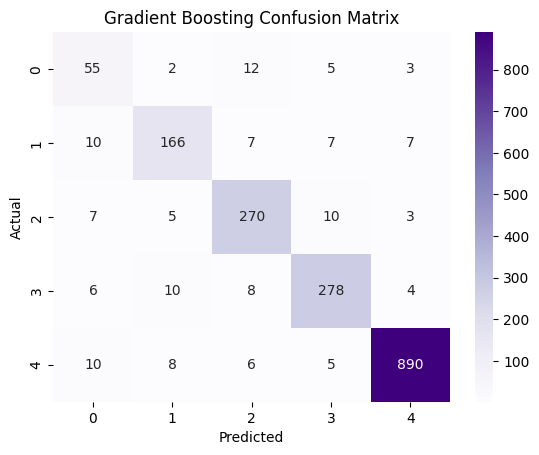

In [27]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

gb.fit(xtrain, ytrain)

# Training
print("Training Score : ", gb.score(xtrain, ytrain) * 100)

# Testing
print("Testing Score : ", gb.score(xtest, ytest) * 100)

#prediction
y_pred_gb = gb.predict(xtest)

# Accuracy Score
ac = accuracy_score(ytest, y_pred_gb)
print("Accuracy Score : ", ac * 100)

# Classification Report
cr = classification_report(ytest, y_pred_gb)
print(cr)

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_gb)
sns.heatmap(cm, annot=True, cmap='Purples', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

# Performing AdaBoostClassifier

Training Score :  91.47157190635451
Testing Score :  93.1438127090301
Accuracy Score :  93.1438127090301
              precision    recall  f1-score   support

         0.0       0.90      0.68      0.77        77
         1.0       0.94      0.85      0.90       197
         2.0       0.94      0.92      0.93       295
         3.0       0.89      0.92      0.90       306
         4.0       0.94      0.98      0.96       919

    accuracy                           0.93      1794
   macro avg       0.92      0.87      0.89      1794
weighted avg       0.93      0.93      0.93      1794



Text(0.5, 1.0, 'AdaBoost Confusion Matrix')

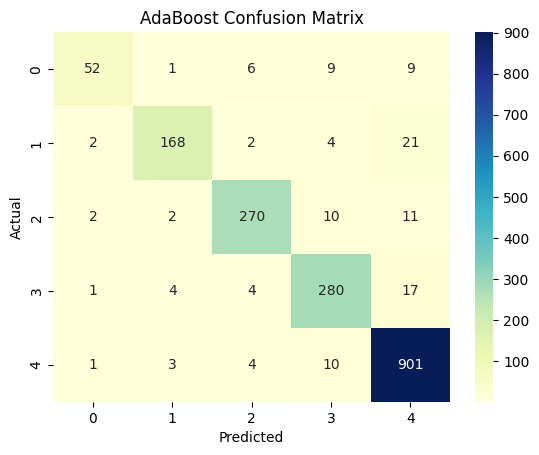

In [28]:
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

ada.fit(xtrain, ytrain)

#Training 
print("Training Score : ", ada.score(xtrain, ytrain) * 100)
#Testing 
print("Testing Score : ", ada.score(xtest, ytest) * 100)

#prediction
y_pred_ada = ada.predict(xtest)

# Accuracy Score
ac = accuracy_score(ytest, y_pred_ada)
print("Accuracy Score : ", ac * 100)

# Classification Report
cr = classification_report(ytest, y_pred_ada)   
print(cr)

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_ada)
sns.heatmap(cm, annot=True, cmap='YlGnBu', fmt='d')
plt.xlabel("Predicted")     
plt.ylabel("Actual")
plt.title("AdaBoost Confusion Matrix")

## Performing Bagging Classifier

In [33]:
bc = BaggingClassifier(n_estimators=100, random_state=42)

In [34]:
bc.fit(xtrain, ytrain)

#training
print("Training Score : ", bc.score(xtrain, ytrain) * 100)
#testing
print("Testing Score : ", bc.score(xtest, ytest) * 100)

Training Score :  100.0
Testing Score :  92.86510590858417


Accuracy Score :  92.86510590858417
              precision    recall  f1-score   support

         0.0       0.67      0.71      0.69        77
         1.0       0.86      0.86      0.86       197
         2.0       0.91      0.93      0.92       295
         3.0       0.90      0.91      0.90       306
         4.0       0.98      0.97      0.98       919

    accuracy                           0.93      1794
   macro avg       0.86      0.87      0.87      1794
weighted avg       0.93      0.93      0.93      1794



Text(0.5, 1.0, 'Bagging Classifier Confusion Matrix')

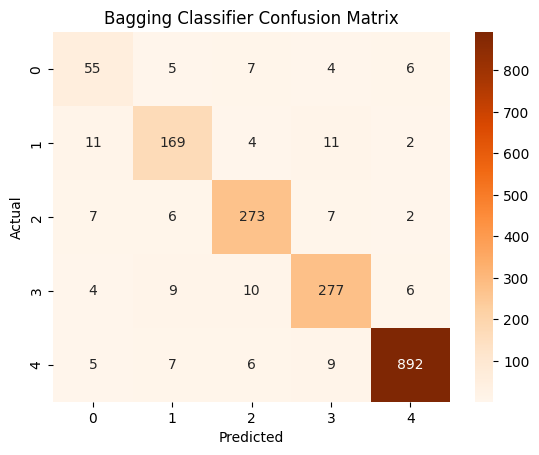

In [35]:
#prediction
y_pred_bc = bc.predict(xtest)

#accuracy score
ac = accuracy_score(ytest, y_pred_bc)
print("Accuracy Score : ", ac * 100)

#classification report
cr = classification_report(ytest, y_pred_bc)
print(cr)

#confusion matrix
cm = confusion_matrix(ytest, y_pred_bc)
sns.heatmap(cm, annot=True, cmap='Oranges', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bagging Classifier Confusion Matrix")

Accuracy Score :  92.86510590858417
              precision    recall  f1-score   support

         0.0       0.67      0.71      0.69        77
         1.0       0.86      0.86      0.86       197
         2.0       0.91      0.93      0.92       295
         3.0       0.90      0.91      0.90       306
         4.0       0.98      0.97      0.98       919

    accuracy                           0.93      1794
   macro avg       0.86      0.87      0.87      1794
weighted avg       0.93      0.93      0.93      1794



Text(0.5, 1.0, 'Bagging Classifier Confusion Matrix')

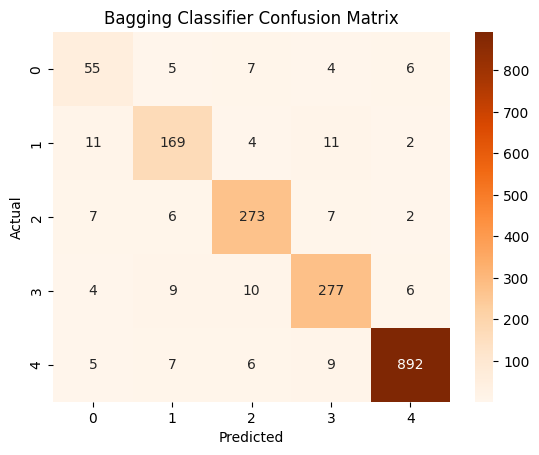

In [36]:
#prediction
y_pred_bc = bc.predict(xtest)

#accuracy score
ac = accuracy_score(ytest, y_pred_bc)
print("Accuracy Score : ", ac * 100)

#classification report
cr = classification_report(ytest, y_pred_bc)
print(cr)

#confusion matrix
cm = confusion_matrix(ytest, y_pred_bc)
sns.heatmap(cm, annot=True, cmap='Oranges', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bagging Classifier Confusion Matrix")

Training Score :  100.0
Testing Score :  92.86510590858417
Accuracy Score :  92.86510590858417
              precision    recall  f1-score   support

         0.0       0.67      0.71      0.69        77
         1.0       0.86      0.86      0.86       197
         2.0       0.91      0.93      0.92       295
         3.0       0.90      0.91      0.90       306
         4.0       0.98      0.97      0.98       919

    accuracy                           0.93      1794
   macro avg       0.86      0.87      0.87      1794
weighted avg       0.93      0.93      0.93      1794



Text(0.5, 1.0, 'Bagging Classifier Confusion Matrix')

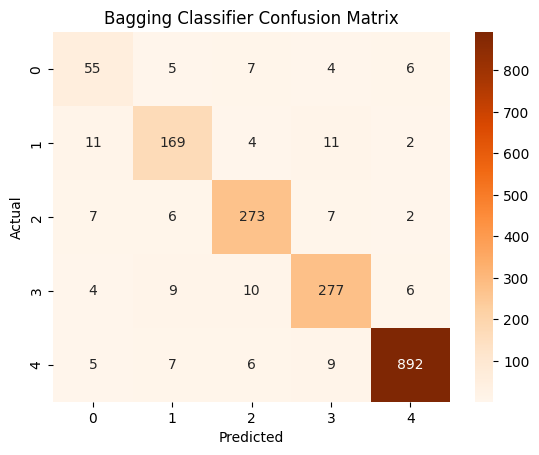

In [37]:
bc = BaggingClassifier(n_estimators=100, random_state=42)

bc.fit(xtrain, ytrain)

#training
print("Training Score : ", bc.score(xtrain, ytrain) * 100)
#testing
print("Testing Score : ", bc.score(xtest, ytest) * 100)

#prediction
y_pred_bc = bc.predict(xtest)

#accuracy score
ac = accuracy_score(ytest, y_pred_bc)
print("Accuracy Score : ", ac * 100)

#classification report
cr = classification_report(ytest, y_pred_bc)
print(cr)

#confusion matrix
cm = confusion_matrix(ytest, y_pred_bc)
sns.heatmap(cm, annot=True, cmap='Oranges', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bagging Classifier Confusion Matrix")

# Performing ExtraTreesClassifier

In [ ]:
etc = ExtraTreesClassifier(n_estimators=100, random_state=42)

etc.fit(xtrain, ytrain)
#training
print("Training Score : ", etc.score(xtrain, ytrain) * 100)
#testing
print("Testing Score : ", etc.score(xtest, ytest) * 100)

#prediction
y_pred_etc = etc.predict(xtest)



#accuracy score
ac = accuracy_score(ytest, y_pred_etc)
print("Accuracy Score : ", ac * 100)

#classification report
cr = classification_report(ytest, y_pred_etc)   
print(cr)

#confusion matrix
cm = confusion_matrix(ytest, y_pred_etc)
sns.heatmap(cm, annot=True, cmap='YlGnBu', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Extra Trees Classifier Confusion Matrix")

# Performing VotingClassifier

In [ ]:
vt = VotingClassifier(estimators=[('rf', rf), ('dt', dt), ('xgb', xgb), ('svm', svm), ('gb', gb), ('ada', ada), ('bc', bc), ('etc', etc)], voting='hard')

vt.fit(xtrain, ytrain)

#training
print("Training Score : ", vt.score(xtrain, ytrain) * 100)
#testing
print("Testing Score : ", vt.score(xtest, ytest) * 100)

#prediction
y_pred_vt = vt.predict(xtest)

#accuracy score
ac = accuracy_score(ytest, y_pred_vt)
print("Accuracy Score : ", ac * 100)

#classification report
cr = classification_report(ytest, y_pred_vt)
print(cr)

#confusion matrix
cm = confusion_matrix(ytest, y_pred_vt)
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Voting Classifier Confusion Matrix")